<a href="https://colab.research.google.com/github/AI-is-out-there/neural-network-skills-review/blob/main/vanilla-code/task2-2_ppg_unsupervised_clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PPG Activity Clustering with Feature Extraction + PCA + KMeans

Vanilla notebook for task 2.2. The dataset contains short wearable-signal windows with one PPG channel and three motion channels. We cluster the windows without using activity labels during training and compare the resulting clusters with `sit`, `walk`, and `run` only at the evaluation stage.

## План

1. Загрузить подготовленный subset `PPG + motion`
2. Нормализовать окна
3. Извлечь простые временные, частотные и пиковые признаки
4. Построить эмбеддинги через `PCA`
5. Кластеризовать окна и сравнить результат с истинными метками активности

In [13]:
# If needed in Colab or a clean environment, uncomment the line below.
!pip install scikit-learn scipy seaborn -q


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [14]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.signal import find_peaks, welch
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
from sklearn.preprocessing import StandardScaler

In [15]:
data_path = Path('../dataset/task2_2-ppg-activity-clustering.npz')
if not data_path.exists():
    data_path = Path('dataset/task2_2-ppg-activity-clustering.npz')

data = np.load(data_path, allow_pickle=True)
X = data['X'].astype(np.float32)
y = data['y']
label_names = data['label_names']
channel_names = data['channel_names']
subject_id = data['subject_id']
meta = json.loads(str(data['meta_json']))

print('X shape:', X.shape)
print('label_names:', label_names)
print('channel_names:', channel_names)
print(meta)

X shape: (27, 4000, 4)
label_names: ['sit' 'walk' 'run']
channel_names: ['pleth_1' 'a_x' 'a_y' 'a_z']
{'source': 'PhysioNet Pulse Transit Time PPG Dataset v1.1.0', 'sampling_rate_hz': 500, 'window_seconds': 8, 'step_seconds': 8, 'shape': [27, 4000, 4], 'selected_subjects': [1, 2, 3], 'channels': ['pleth_1', 'a_x', 'a_y', 'a_z'], 'selection_rule': 'first three non-overlapping 8-second windows from each recording after trimming first and last 5 seconds'}


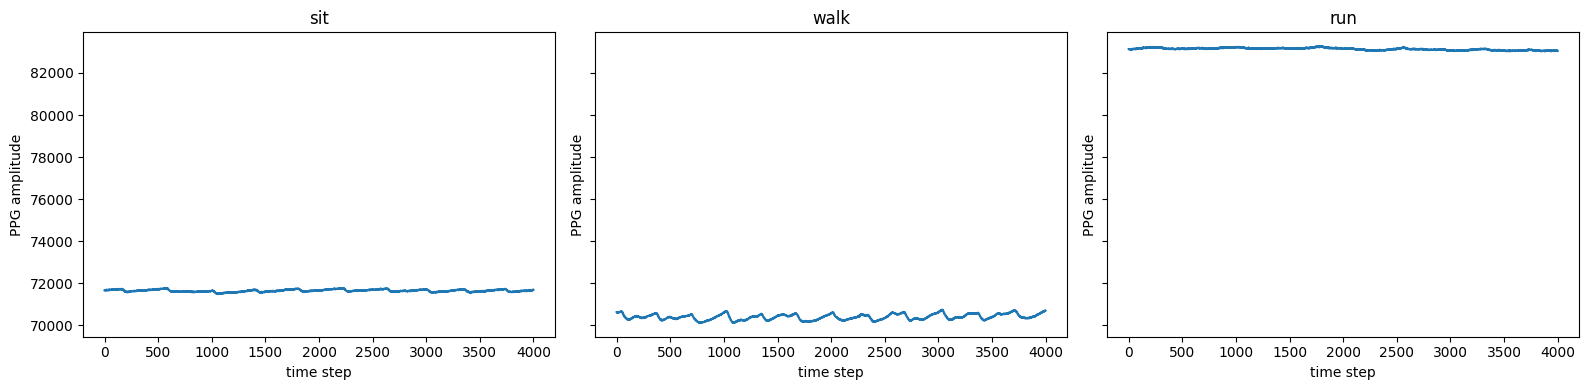

In [16]:
ppg_idx = list(channel_names).index('pleth_1')
fig, axes = plt.subplots(1, len(label_names), figsize=(16, 4), sharey=True)
for ax, class_id in zip(axes, range(len(label_names))):
    idx = np.where(y == class_id)[0][0]
    ax.plot(X[idx, :, ppg_idx], lw=1.6)
    ax.set_title(str(label_names[class_id]))
    ax.set_xlabel('time step')
    ax.set_ylabel('PPG amplitude')
plt.tight_layout()

In [17]:
# Per-window z-score so clustering focuses on waveform shape and movement pattern.
X_norm = (X - X.mean(axis=1, keepdims=True)) / (X.std(axis=1, keepdims=True) + 1e-6)

def extract_features(window, fs=500):
    feature_row = []
    for ch in range(window.shape[1]):
        signal = window[:, ch]
        diff = np.diff(signal)
        freqs, psd = welch(signal, fs=fs, nperseg=min(1024, len(signal)))
        dominant_freq = float(freqs[np.argmax(psd)])
        band_power = float(psd[(freqs >= 0.5) & (freqs < 3.0)].sum())
        feature_row.extend([
            signal.std(),
            np.ptp(signal),
            np.mean(np.abs(diff)),
            np.std(diff),
            dominant_freq,
            band_power,
        ])

        if ch == ppg_idx:
            peaks, _ = find_peaks(signal, distance=int(0.25 * fs), prominence=0.2)
            ibi = np.diff(peaks) / fs if len(peaks) > 1 else np.array([0.0])
            feature_row.extend([
                len(peaks) / (len(signal) / fs),
                float(ibi.mean()),
                float(ibi.std()),
            ])
    return feature_row

features = np.array([extract_features(window) for window in X_norm], dtype=np.float32)
print('feature matrix:', features.shape)

feature matrix: (27, 27)


In [18]:
features_scaled = StandardScaler().fit_transform(features)
embeddings = PCA(n_components=6, random_state=42).fit_transform(features_scaled)

kmeans = KMeans(n_clusters=len(label_names), random_state=42, n_init=20)
clusters_kmeans = kmeans.fit_predict(embeddings)

agglo = AgglomerativeClustering(n_clusters=len(label_names))
clusters_agglo = agglo.fit_predict(embeddings)

for name, clusters in [('KMeans', clusters_kmeans), ('Agglomerative', clusters_agglo)]:
    ari = adjusted_rand_score(y, clusters)
    nmi = normalized_mutual_info_score(y, clusters)
    sil = silhouette_score(embeddings, clusters)
    print(name)
    print('  ARI:', round(ari, 4))
    print('  NMI:', round(nmi, 4))
    print('  Silhouette:', round(sil, 4))

KMeans
  ARI: 0.5593
  NMI: 0.7121
  Silhouette: 0.5187
Agglomerative
  ARI: 0.5593
  NMI: 0.7121
  Silhouette: 0.5187


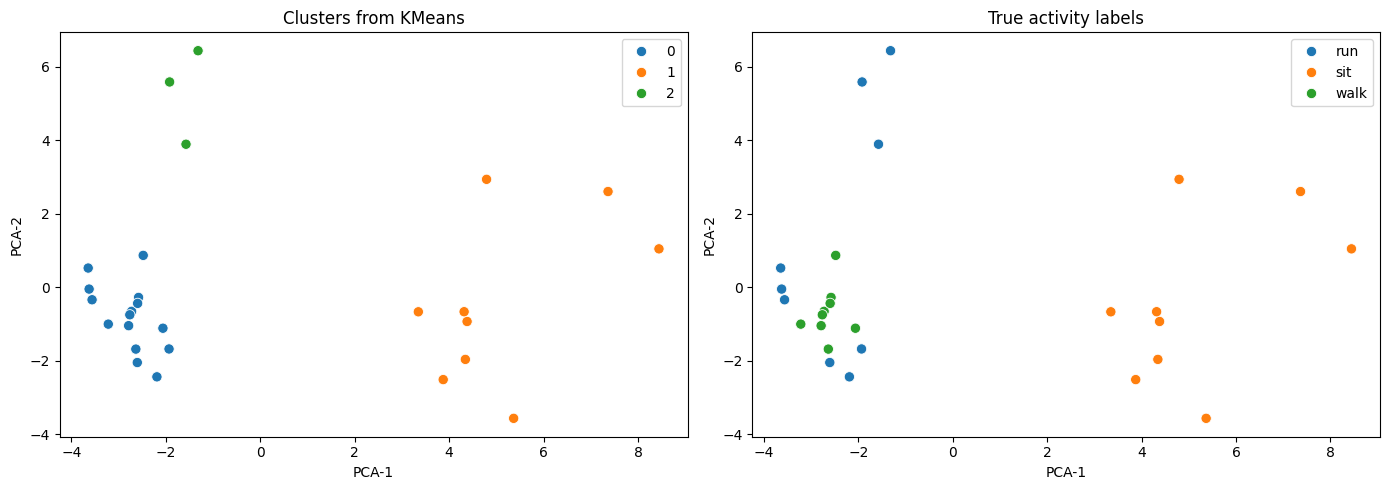

In [19]:
clusters = clusters_kmeans
true_names = [str(label_names[idx]) for idx in y]
points_2d = PCA(n_components=2, random_state=42).fit_transform(features_scaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=points_2d[:, 0], y=points_2d[:, 1], hue=clusters, palette='tab10', ax=axes[0], s=55)
axes[0].set_title('Clusters from KMeans')

sns.scatterplot(x=points_2d[:, 0], y=points_2d[:, 1], hue=true_names, palette='tab10', ax=axes[1], s=55)
axes[1].set_title('True activity labels')

for ax in axes:
    ax.set_xlabel('PCA-1')
    ax.set_ylabel('PCA-2')
plt.tight_layout()

true_label,run,sit,walk
cluster,,,
0,6,0,9
1,0,9,0
2,3,0,0


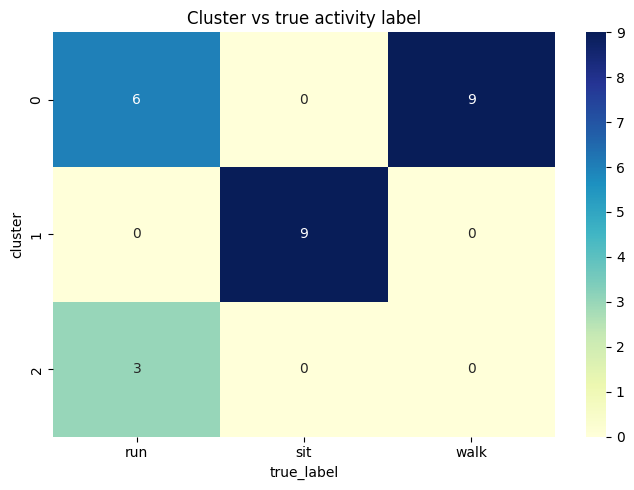

In [20]:
comparison = pd.crosstab(
    pd.Series(clusters, name='cluster'),
    pd.Series(true_names, name='true_label')
)
display(comparison)

plt.figure(figsize=(7, 5))
sns.heatmap(comparison, annot=True, fmt='d', cmap='YlGnBu')
plt.title('Cluster vs true activity label')
plt.tight_layout()

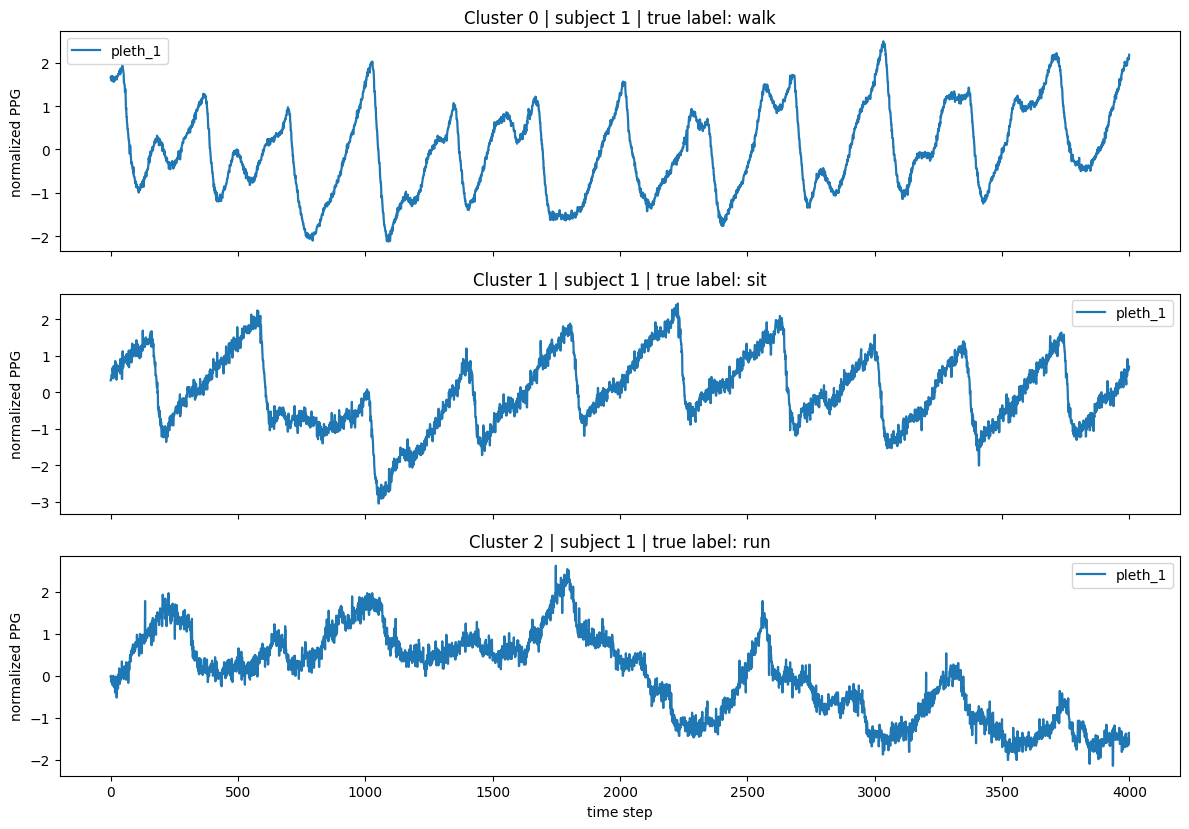

In [21]:
cluster_ids = sorted(np.unique(clusters))
fig, axes = plt.subplots(len(cluster_ids), 1, figsize=(12, 2.8 * len(cluster_ids)), sharex=True)
if len(cluster_ids) == 1:
    axes = [axes]

for ax, cluster_id in zip(axes, cluster_ids):
    idx = np.where(clusters == cluster_id)[0][0]
    ax.plot(X_norm[idx, :, ppg_idx], label='pleth_1', lw=1.6)
    ax.set_title(f'Cluster {cluster_id} | subject {subject_id[idx]} | true label: {true_names[idx]}')
    ax.set_ylabel('normalized PPG')
    ax.legend()

axes[-1].set_xlabel('time step')
plt.tight_layout()